In [1]:
import os
from dotenv import load_dotenv
from langchain_core.tools import create_retriever_tool
from pydantic import SecretStr
from langchain_groq import ChatGroq
load_dotenv()

C:\Softwares\Python\pythoncore-3.14-64\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
C:\Users\ybalasaraswa\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
groq_api_key = os.getenv("GROQ_API_KEY")
# llm = ChatGroq(
#     api_key=SecretStr(groq_api_key) if groq_api_key else None,
#     model="openai/gpt-oss-120b"
# )

In [3]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_ollama import OllamaEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

urls = [
    "https://docs.langchain.com/oss/python/langchain/overview",
    "https://docs.langchain.com/oss/python/langgraph/thinking-in-langgraph",
    "https://docs.langchain.com/oss/python/langgraph/application-structure"
]

# Load each URL separately and flatten into a single document list.
docs = []
for url in urls:
    docs.extend(WebBaseLoader(url).load())
docs

USER_AGENT environment variable not set, consider setting it to identify your requests.


[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langchain/overview', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain is an open source framework with a prebuilt agent architecture and integrations for any model or tool—so you can build agents that adapt as fast as the ecosystem evolves', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainSkip to main contentJoin us May 13th & May 14th at Interrupt, the Agent Conference by LangChain. Buy tickets >Docs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryStreamingStructured outputMiddlewareOverviewPrebuilt middlewareCustom middlewareFrontendOverviewPatternsIntegrationsAdvanced usageGuardrailsRuntimeContext engineeringModel C

In [4]:
# docs is already a flat list of Document objects after .extend()
doc_list = docs

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
texts = text_splitter.split_documents(doc_list)

vectorStore = FAISS.from_documents(texts, OllamaEmbeddings(model="nomic-embed-text"))

In [5]:
retriever = vectorStore.as_retriever()

In [6]:
retriever.invoke("How does LangGraph support RAG?")

[Document(id='6122309a-d9b6-4b6a-89d0-c003f278913a', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/thinking-in-langgraph', 'title': 'Thinking in LangGraph - Docs by LangChain', 'description': 'Learn how to think about building agents with LangGraph', 'language': 'en'}, page_content='In this walkthrough, we’ll guide you through the thought process of building a customer support email agent with LangGraph.\n\u200bStart with the process you want to automate\nImagine that you need to build an AI agent that handles customer support emails. Your product team has given you these requirements:\nThe agent should:'),
 Document(id='8018df2c-a40f-42a6-9668-81411cfa44f7', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/application-structure', 'title': 'Application structure - Docs by LangChain', 'language': 'en'}, page_content='Connect these docs to Claude, VSCode, and more via MCP for real-time answers.Edit this page on GitHub or file an issue.Was this p

In [7]:
## retriever to retroactive tools
from langchain_core.tools import create_retriever_tool
retrieval_tool = create_retriever_tool(
    retriever,
    name="retriever_vector_db_blog",
    description="search and run information retrieval on a vector database of the LangGraph documentation, useful for answering questions about how to use LangChain and LangGraph",
)

### langchain blogs --separate vector DB

In [8]:
urls = [
    "https://docs.langchain.com/oss/python/langchain/overview",
    "https://docs.langchain.com/oss/python/langchain/philosophy",
    "https://docs.langchain.com/oss/python/langchain/agents"
]

# Load each URL separately and flatten into a single document list.
docs = []
for url in urls:
    docs.extend(WebBaseLoader(url).load())
docs


# docs is already a flat list of Document objects after .extend()
doc_list = docs

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
texts = text_splitter.split_documents(doc_list)

vectorStore = FAISS.from_documents(texts, OllamaEmbeddings(model="nomic-embed-text"))

retriever = vectorStore.as_retriever()
## retriever to retroactive tools
from langchain_core.tools import create_retriever_tool
retrieval_langChain_tool = create_retriever_tool(
    retriever,
    name="retriever_vector_langChain_blog",
    description="search and run information retrieval on a vector database of the LangChain documentation, useful for answering questions about how to use LangChain and langchain",
)

In [9]:
tools = [retrieval_tool, retrieval_langChain_tool]

### LangGraph workflow

In [10]:
from typing import Annotated, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class AgenticRAGState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    final_answer: str

C:\Users\ybalasaraswa\AppData\Roaming\Python\Python314\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [11]:
def agent(state):
    """
    Invokes the agent model to generate a response based on the current state Given the question it will decide to retrieve using the retrieval tool or simply end
    Args:
            state(messages): the current state
    :return: dict: the updated state with the agent response append to messages
    """

    print("-----CALL AGENT -----")
    messages = state["messages"]  # fix: was state["message"] (singular)
    model = ChatGroq(
        api_key=SecretStr(groq_api_key) if groq_api_key else None,
        model="openai/gpt-oss-120b"
    )
    model = model.bind_tools(tools)
    response = model.invoke(messages)
    return {"messages": [response]}  # fix: was {"message": response}


In [12]:
from typing import Annotated, Literal, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate

from pydantic import BaseModel, Field

In [13]:
### Edges
def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """

    print("---CHECK RELEVANCE---")

    # Data model
    class grade(BaseModel):
        """Binary score for relevance check."""

        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    # LLM
    model = ChatGroq(model="openai/gpt-oss-120b")

    # LLM with tool and validation
    llm_with_tool = model.with_structured_output(grade)

    # Prompt
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )

    # Chain
    chain = prompt | llm_with_tool

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"

    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite"

In [14]:
def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """
    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Prompt (equivalent to rlm/rag-prompt from hub)
    prompt = ChatPromptTemplate.from_messages([
        ("human", (
            "You are an assistant for question-answering tasks. "
            "Use the following pieces of retrieved context to answer the question. "
            "If you don't know the answer, just say that you don't know. "
            "Use three sentences maximum and keep the answer concise.\n\n"
            "Question: {question}\n\nContext: {context}\n\nAnswer:"
        ))
    ])

    # LLM
    llm = ChatGroq(model="openai/gpt-oss-120b")

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

In [15]:
def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # Grader
    model = ChatGroq(model="openai/gpt-oss-120b")
    response = model.invoke(msg)
    return {"messages": [response]}

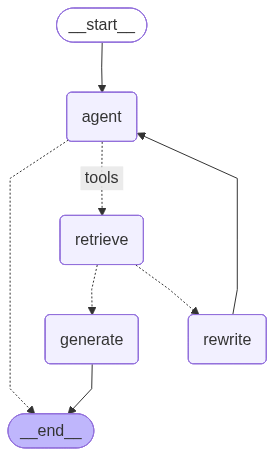

In [16]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Define a new graph
workflow = StateGraph(AgenticRAGState)  # fix: was AgentState (undefined)

# Define the nodes we will cycle between
workflow.add_node("agent", agent)  # agent
retrieve = ToolNode([retrieval_tool, retrieval_langChain_tool])  # fix: wrong variable names
workflow.add_node("retrieve", retrieve)  # retrieval
workflow.add_node("rewrite", rewrite)  # Re-writing the question
workflow.add_node(
    "generate", generate
)  # Generating a response after we know the documents are relevant
# Call agent node to decide to retrieve or not
workflow.add_edge(START, "agent")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "agent",
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# Compile
graph = workflow.compile()
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


In [18]:
result = graph.invoke({"messages": [HumanMessage(content="What is LangGraph?")]})

# Pretty-print the conversation
print("\n" + "="*60)
print("🤖 AGENTIC RAG - RESULT")
print("="*60)
for msg in result["messages"]:
    role = msg.__class__.__name__.replace("Message", "").upper()
    icon = {"HUMAN": "👤", "AI": "🤖", "TOOL": "🔧"}.get(role, "💬")
    print(f"\n{icon} [{role}]")
    print("-" * 40)
    print(msg.content)
print("\n" + "="*60)


-----CALL AGENT -----

🤖 AGENTIC RAG - RESULT

👤 [HUMAN]
----------------------------------------
What is Langgraph?

🤖 [AI]
----------------------------------------
**LangGraph** is an open‑source Python library (maintained by the LangChain team) that makes it easy to build **state‑driven, multi‑step workflows** (or “graphs”) powered by large language models (LLMs).  

---

## 1️⃣ The core idea

- **Graphs, not just chains** – While LangChain introduced the concept of *chains* (a linear sequence of LLM calls and other tools), many real‑world applications need branching, loops, conditional logic, or parallel execution. LangGraph lets you describe those more complex control flows as a **directed graph** of “nodes”.

- **Explicit state** – Each step reads from and writes to a shared **state dictionary** (often called `graph_state`). This makes it clear what data is being passed around, enables easy debugging, and lets you resume or replay a workflow from any point.

- **Composable nodes*